In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [24]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

OUTPUTS_BENCHMARK_10Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_10y"
OUTPUTS_REWARD_DIR = f"{PROJECT_ROOT}/outputs/reward_comparison"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_RESULTS_10Y_DIR = f"{PROJECT_ROOT}/outputs/results_tables_figures_10y"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    OUTPUTS_BENCHMARK_10Y_DIR,
    OUTPUTS_REWARD_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_RESULTS_10Y_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

ASSETS = master_cfg["assets"]

print("OUTPUTS_RESULTS_10Y_DIR:", OUTPUTS_RESULTS_10Y_DIR)
print("ASSETS:", ASSETS)

OUTPUTS_RESULTS_10Y_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/results_tables_figures_10y
ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']


In [25]:
# ============================================================
# CELL 04 — Load benchmark, reward, and rollout files
# ============================================================

supp_benchmark_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_benchmark_metrics_10y.csv")
leaderboard_test_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_leaderboard_test_10y.csv")
supp_interpretation_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/supplementary_interpretation_10y.csv")

reward_comparison_realistic_10y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_realistic_10y.csv")
reward_comparison_test_10y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_test_10y.csv")

eq_test_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/equal_weight_rollout_test_10y.csv")
buyhold_test_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/buyhold_equalweight_rollout_test_10y.csv")
rand_test_10y = pd.read_csv(f"{OUTPUTS_BENCHMARK_10Y_DIR}/random_policy_rollout_test_10y.csv")

mlp_test_10y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/mlp_ppo_10y/test_rollout_best.csv")
lstm_test_10y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/lstm_ppo_10y/test_rollout_best.csv")
costaware_test_10y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/costaware_train_test_rollout_realistic_10y.csv")
nocost_test_10y = pd.read_csv(f"{OUTPUTS_REWARD_DIR}/nocost_train_test_rollout_realistic_10y.csv")

print("supp_benchmark_10y:", supp_benchmark_10y.shape)
print("leaderboard_test_10y:", leaderboard_test_10y.shape)
print("reward_comparison_test_10y:", reward_comparison_test_10y.shape)

supp_benchmark_10y: (21, 12)
leaderboard_test_10y: (7, 7)
reward_comparison_test_10y: (4, 13)


In [26]:
# ============================================================
# CELL 05 — Table S1: Supplementary 10Y benchmark table (val + test)
# ============================================================

table_s1 = supp_benchmark_10y[
    supp_benchmark_10y["split"].isin(["val", "test"])
][[
    "model",
    "split",
    "cumulative_return",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
]].copy()

table_s1 = table_s1.sort_values(["split", "cumulative_return"], ascending=[True, False]).reset_index(drop=True)
display(table_s1)

,model,split,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost
0,BuyHold_EqualWeight,test,0.780724,1.935857,-0.113614,0.000000,0.000000
1,Equal_Weight,test,0.724209,1.991219,-0.102027,0.000000,0.000000
2,Transformer10Y_NoCostTrain,test,0.645066,1.904087,-0.110084,0.146739,0.073516
3,MLP_PPO_10Y,test,0.636315,2.213623,-0.104044,0.227882,0.114169
4,LSTM_PPO_10Y,test,0.602773,1.876290,-0.107737,0.146698,0.073496
5,Transformer10Y_CostAwareTrain,test,0.562732,2.057607,-0.123749,0.271854,0.136199
6,Random_Policy,test,0.295984,2.013152,-0.157984,0.641560,0.321422
7,Equal_Weight,val,-0.032347,0.032602,-0.259889,0.000000,0.000000
8,MLP_PPO_10Y,val,-0.035776,0.282151,-0.265646,0.223358,0.112349
9,BuyHold_EqualWeight,val,-0.036455,0.017971,-0.270693,0.000000,0.000000


In [27]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table_s1)

https://docs.google.com/spreadsheets/d/1-MWhAGwE3z6WWVkjtUZRsBU-phZpmGlHbawaer1RhyU/edit#gid=0


In [28]:
# ============================================================
# CELL 06 — Table S2: Supplementary 10Y test leaderboard
# ============================================================

table_s2 = leaderboard_test_10y.copy()
display(table_s2)

,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,rank_test_cumret
0,BuyHold_EqualWeight,0.780724,1.935857,-0.113614,0.000000,0.000000,1
1,Equal_Weight,0.724209,1.991219,-0.102027,0.000000,0.000000,2
2,Transformer10Y_NoCostTrain,0.645066,1.904087,-0.110084,0.146739,0.073516,3
3,MLP_PPO_10Y,0.636315,2.213623,-0.104044,0.227882,0.114169,4
4,LSTM_PPO_10Y,0.602773,1.876290,-0.107737,0.146698,0.073496,5
5,Transformer10Y_CostAwareTrain,0.562732,2.057607,-0.123749,0.271854,0.136199,6
6,Random_Policy,0.295984,2.013152,-0.157984,0.641560,0.321422,7


In [29]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table_s2)

https://docs.google.com/spreadsheets/d/1ABcd9lXtq5_8-JdHVqWlsYdqEj4vMP4Gt-dYIxxpZeY/edit#gid=0


In [30]:
# ============================================================
# CELL 07 — Table S3: Reward comparison on 10Y test
# ============================================================

table_s3 = reward_comparison_test_10y[[
    "evaluation_mode",
    "model",
    "split",
    "cumulative_return",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
]].copy()

table_s3 = table_s3.sort_values(["evaluation_mode", "cumulative_return"], ascending=[True, False]).reset_index(drop=True)
display(table_s3)

,evaluation_mode,model,split,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost
0,cost_aware_realistic,Transformer10Y_NoCostTrain,test,0.645066,1.904087,-0.110084,0.146739,0.073516
1,cost_aware_realistic,Transformer10Y_CostAwareTrain,test,0.562732,2.057607,-0.123749,0.271854,0.136199
2,no_cost_frictionless,Transformer10Y_CostAwareTrain,test,0.790796,2.057607,-0.109359,0.271854,0.000000
3,no_cost_frictionless,Transformer10Y_NoCostTrain,test,0.770574,1.904087,-0.106777,0.146739,0.000000


In [31]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table_s3)

https://docs.google.com/spreadsheets/d/17STN0kEPp8wuxRijpZ2QJDeubWmD-5aW18YZ_Dgrk4o/edit#gid=0


In [32]:
# ============================================================
# CELL 08 — Table S4: Learned-model-only comparison on 10Y test
# ============================================================

learned_models_10y = [
    "MLP_PPO_10Y",
    "LSTM_PPO_10Y",
    "Transformer10Y_CostAwareTrain",
    "Transformer10Y_NoCostTrain",
]

table_s4 = supp_benchmark_10y[
    (supp_benchmark_10y["split"] == "test") &
    (supp_benchmark_10y["model"].isin(learned_models_10y))
][[
    "model",
    "cumulative_return",
    "sharpe_approx",
    "max_drawdown",
    "avg_turnover",
    "total_trading_cost",
]].copy()

table_s4 = table_s4.sort_values("cumulative_return", ascending=False).reset_index(drop=True)
table_s4["rank_test_cumret"] = np.arange(1, len(table_s4) + 1)
display(table_s4)

,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,rank_test_cumret
0,Transformer10Y_NoCostTrain,0.645066,1.904087,-0.110084,0.146739,0.073516,1
1,MLP_PPO_10Y,0.636315,2.213623,-0.104044,0.227882,0.114169,2
2,LSTM_PPO_10Y,0.602773,1.876290,-0.107737,0.146698,0.073496,3
3,Transformer10Y_CostAwareTrain,0.562732,2.057607,-0.123749,0.271854,0.136199,4


In [33]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table_s4)

https://docs.google.com/spreadsheets/d/1OfemGk2JJ1_rKGOl5KVFvMO46U14UXwNkOCex1NDlfg/edit#gid=0


In [34]:
# ============================================================
# CELL 09 — Save supplementary tables
# ============================================================

table_s1.to_csv(f"{OUTPUTS_RESULTS_10Y_DIR}/table_s1_benchmark_val_test_10y.csv", index=False)
table_s2.to_csv(f"{OUTPUTS_RESULTS_10Y_DIR}/table_s2_test_leaderboard_10y.csv", index=False)
table_s3.to_csv(f"{OUTPUTS_RESULTS_10Y_DIR}/table_s3_reward_comparison_test_10y.csv", index=False)
table_s4.to_csv(f"{OUTPUTS_RESULTS_10Y_DIR}/table_s4_learned_models_test_10y.csv", index=False)

print("Saved supplementary 10Y tables.")

Saved supplementary 10Y tables.


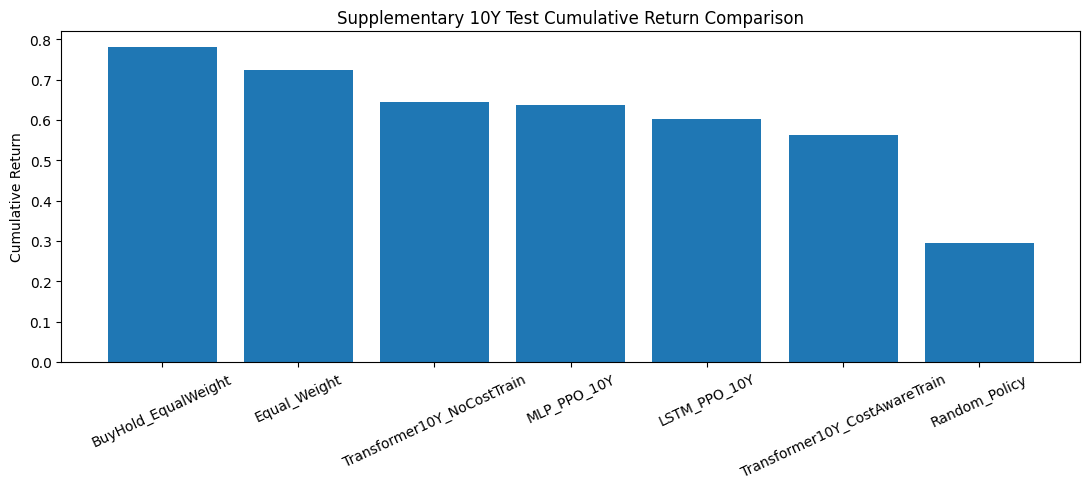

In [35]:
# ============================================================
# CELL 10 — Figure S1: Full supplementary 10Y test cumulative return comparison
# ============================================================

plot_df = supp_benchmark_10y[supp_benchmark_10y["split"] == "test"].copy()
plot_df = plot_df.sort_values("cumulative_return", ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(plot_df["model"], plot_df["cumulative_return"])
plt.title("Supplementary 10Y Test Cumulative Return Comparison")
plt.ylabel("Cumulative Return")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

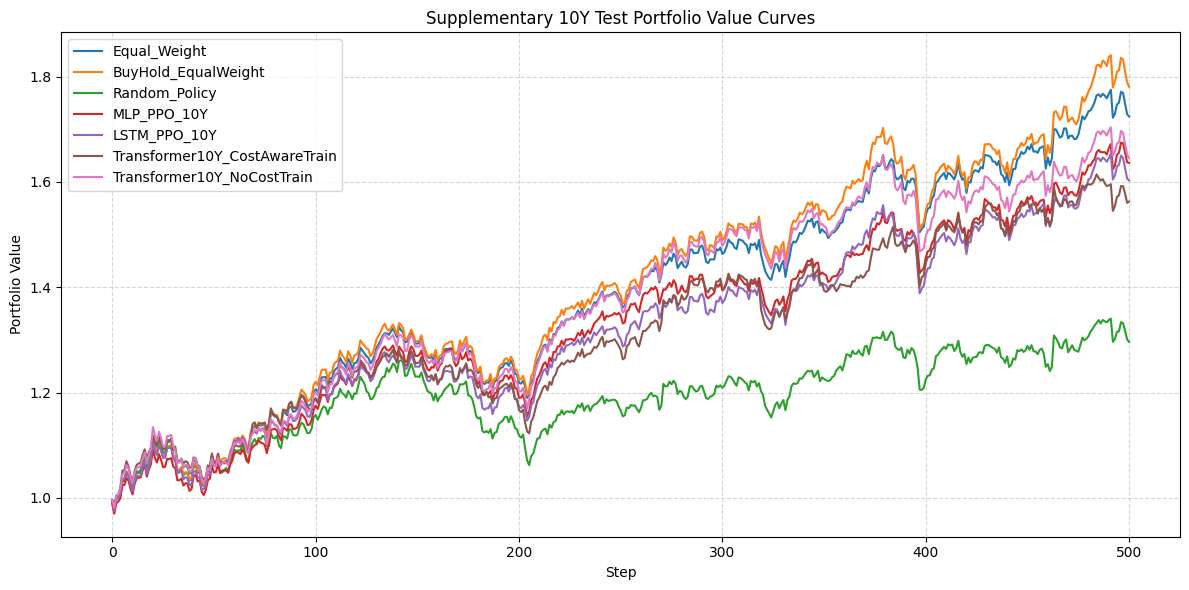

In [36]:
# ============================================================
# CELL 11 — Figure S2: Full supplementary 10Y test portfolio value curves
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(eq_test_10y["portfolio_value"].values, label="Equal_Weight")
plt.plot(buyhold_test_10y["portfolio_value"].values, label="BuyHold_EqualWeight")
plt.plot(rand_test_10y["portfolio_value"].values, label="Random_Policy")
plt.plot(mlp_test_10y["portfolio_value"].values, label="MLP_PPO_10Y")
plt.plot(lstm_test_10y["portfolio_value"].values, label="LSTM_PPO_10Y")
plt.plot(costaware_test_10y["portfolio_value"].values, label="Transformer10Y_CostAwareTrain")
plt.plot(nocost_test_10y["portfolio_value"].values, label="Transformer10Y_NoCostTrain")

plt.title("Supplementary 10Y Test Portfolio Value Curves")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

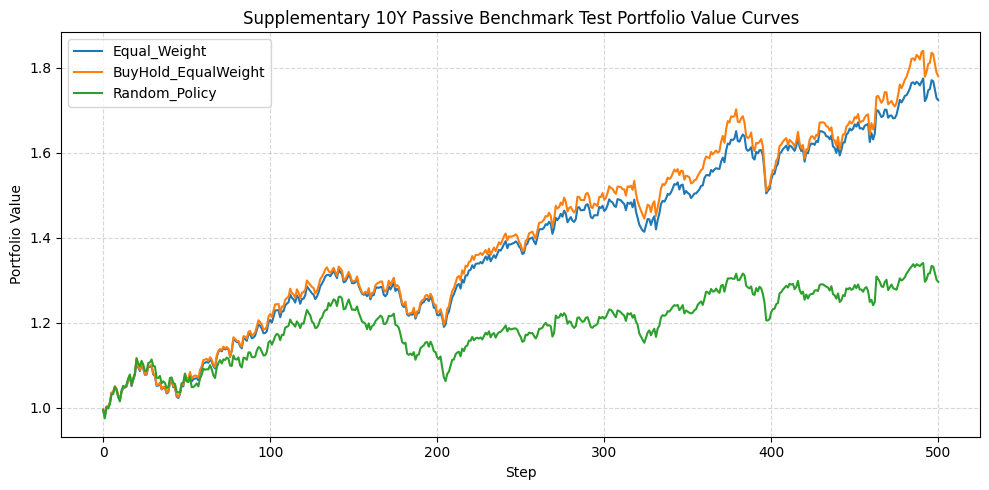

In [37]:
# ============================================================
# CELL 12 — Figure S3: Passive benchmark curves (10Y)
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(eq_test_10y["portfolio_value"].values, label="Equal_Weight")
plt.plot(buyhold_test_10y["portfolio_value"].values, label="BuyHold_EqualWeight")
plt.plot(rand_test_10y["portfolio_value"].values, label="Random_Policy")

plt.title("Supplementary 10Y Passive Benchmark Test Portfolio Value Curves")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

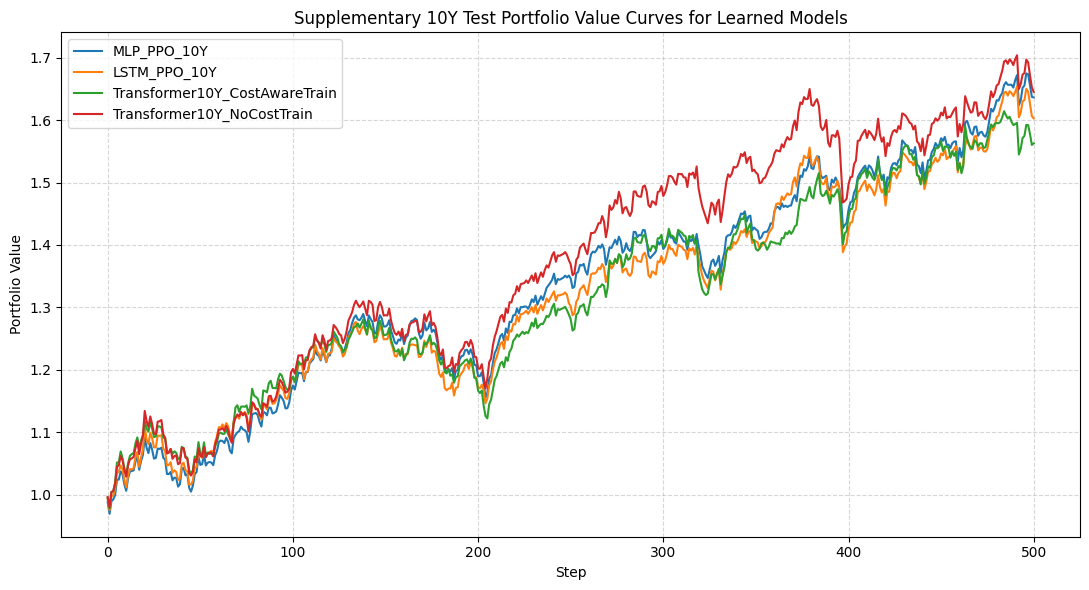

In [38]:
# ============================================================
# CELL 13 — Figure S4: Learned-model-only curves (10Y)
# ============================================================

plt.figure(figsize=(11, 6))
plt.plot(mlp_test_10y["portfolio_value"].values, label="MLP_PPO_10Y")
plt.plot(lstm_test_10y["portfolio_value"].values, label="LSTM_PPO_10Y")
plt.plot(costaware_test_10y["portfolio_value"].values, label="Transformer10Y_CostAwareTrain")
plt.plot(nocost_test_10y["portfolio_value"].values, label="Transformer10Y_NoCostTrain")

plt.title("Supplementary 10Y Test Portfolio Value Curves for Learned Models")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# CELL 14 — Build final interpretation summary
# ============================================================

top_overall = table_s2.iloc[0]
top_learned = table_s4.iloc[0]

supp_results_interpretation = pd.DataFrame([
    {
        "topic": "Supplementary 10Y Benchmark",
        "finding": f"Best overall 10Y test result was {top_overall['model']}",
        "evidence": f"Test cumulative return = {top_overall['cumulative_return']:.6f}",
    },
    {
        "topic": "Supplementary 10Y Learned Models",
        "finding": f"Best learned 10Y test result was {top_learned['model']}",
        "evidence": f"Test cumulative return = {top_learned['cumulative_return']:.6f}",
    },
    {
        "topic": "Supplementary 10Y Passive Baselines",
        "finding": "Equal-weight and buy-and-hold were both highly competitive passive benchmarks",
        "evidence": "Observed in the 10Y test leaderboard and passive benchmark curves",
    },
    {
        "topic": "Supplementary 10Y Reward",
        "finding": "No-cost-trained Transformer outperformed cost-aware-trained Transformer on 10Y test under realistic evaluation",
        "evidence": "Observed in Table S3 and learned-model comparison",
    },
])

display(supp_results_interpretation)

,topic,finding,evidence
0,Supplementary 10Y Benchmark,Best overall 10Y test result was BuyHold_Equal...,Test cumulative return = 0.780724
1,Supplementary 10Y Learned Models,Best learned 10Y test result was Transformer10...,Test cumulative return = 0.645066
2,Supplementary 10Y Passive Baselines,Equal-weight and buy-and-hold were both highly...,Observed in the 10Y test leaderboard and passi...
3,Supplementary 10Y Reward,No-cost-trained Transformer outperformed cost-...,Observed in Table S3 and learned-model comparison


In [40]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=supp_results_interpretation)

https://docs.google.com/spreadsheets/d/15KSOWzlwJNp-sDzo_hdbFWlhPs41mhKIpMls2cq-0hs/edit#gid=0


In [41]:
# ============================================================
# CELL 15 — Save interpretation summary
# ============================================================

supp_results_interpretation.to_csv(
    f"{OUTPUTS_RESULTS_10Y_DIR}/supplementary_results_interpretation_10y.csv",
    index=False
)
print("Saved final supplementary interpretation 10Y.")

Saved final supplementary interpretation 10Y.


In [42]:
# ============================================================
# CELL 16 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_RESULTS_10Y_DIR}/table_s1_benchmark_val_test_10y.csv",
    f"{OUTPUTS_RESULTS_10Y_DIR}/table_s2_test_leaderboard_10y.csv",
    f"{OUTPUTS_RESULTS_10Y_DIR}/table_s3_reward_comparison_test_10y.csv",
    f"{OUTPUTS_RESULTS_10Y_DIR}/table_s4_learned_models_test_10y.csv",
    f"{OUTPUTS_RESULTS_10Y_DIR}/supplementary_results_interpretation_10y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

print("All updated 10Y results notebook checks passed.")

All updated 10Y results notebook checks passed.
